# **Step#1 Data Collection From FAST-NU Website**

## Necessary Libraries

In [137]:
import pandas as pd
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import seaborn as sns

## FAST School of Computing Faculty Data

In [138]:
URL = "https://lhr.nu.edu.pk/faculty/#fsc"
page = requests.get(URL)
print(page)

<Response [200]>


In [139]:
soup = BeautifulSoup(page.content, "html.parser")
soup.find("div", class_="container", id="fsc")

<div class="container" id="fsc">
<br>
<h1 class="mb-2 mt-3">FAST School of Computing Faculty</h1>
<hr class="mt-0 nu-hr mb-0"/>
<div class="container tab-pane active" id="faculty-tab"><br/>
<div class="row">
<div class="col-lg-3 col-md-4 col-sm-6 col-12">
<div class="card facultyCard card-br-0 ml-0 mr-0 pb-0">
<div class="facultyImage">
<img class="card-img-top rounded-circle mt-3 mb-0 d-block mx-auto" src="/media/Faculty/Kashif_Zafar.jpg"/>
</div>
<div class="card-body pr-0 pl-0 pb-0">
<h5 class="text-center">Dr. Kashif Zafar</h5>
<p class="small text-center font-italic">Professor  &amp; HOD 
                        
                        
                         <br> PhD Approved Supervisor 
                        
                        </br></p>
<p class="mb-0 text-center">kashif.zafar@nu.edu.pk</p>
<!--  <p class="mt-0 small text-center">ext no: 569</p> -->
<a class="faculty-link" href="/fsc/facultyProfile/1238"></a>
</div>
</div>
</div>
<div class="col-lg-3 col-md-4 col-sm-6

In [140]:
divs = soup.find(class_="container", id="fsc").find_all(
    class_="col-lg-3 col-md-4 col-sm-6 col-12"
)

## Data Frame Preparation

In [141]:
joint_data = pd.DataFrame()

data_list = []

for div in divs:
    faculty_link = div.find("a", class_="faculty-link")
    href = faculty_link["href"] if faculty_link else None

    new_data = {
        "ID": href.split("/")[-1] if href else None,
        "Name": (
            div.find("h5", class_="text-center").text.strip()
            if div.find("h5", class_="text-center")
            else None
        ),
        "Designation": (
            div.find("p", class_="small text-center font-italic")
            .get_text(separator=" ", strip=True)
            .split("HEC Approved")[0]
            .strip()
            if div.find("p", class_="small text-center font-italic")
            else None
        ),
        "Email": (
            div.find("p", class_="mb-0 text-center").text.strip()
            if div.find("p", class_="mb-0 text-center")
            else None
        ),
        "Department": href.split("/")[1] if href else None,
    }

    data_list.append(new_data)

joint_data = pd.DataFrame(data_list)
joint_data.head()

,ID,Name,Designation,Email,Department
0,1238,Dr. Kashif Zafar,Professor & HOD PhD Approved Supervisor,kashif.zafar@nu.edu.pk,fsc
1,4027,Dr. Aamir Wali,Professor & HOD (AI&DS) PhD Approved Supervisor,aamir.wali@nu.edu.pk,fsc
2,6174,Dr. Arshad Ali,Professor & HOD (CY) PhD Approved Supervisor,arshad.ali1@nu.edu.pk,fsc
3,4391,Dr. Asif Mahmood Gillani,Professor PhD Approved Supervisor,asif.gilani@nu.edu.pk,fsc
4,6113,Dr. Asma Naseer,Professor PhD Approved Supervisor On Leave,asma.naseer@nu.edu.pk,fsc


## Data import to .csv file

In [142]:
joint_data.to_csv("fsc.csv")

## Department of Electrical Engineering Faculty Data

In [143]:
URL = "https://lhr.nu.edu.pk/faculty/#ee"
page = requests.get(URL)
print(page)

<Response [200]>


In [144]:
soup = BeautifulSoup(page.content, "html.parser")
soup.find("div", class_="container", id="ee")

<div class="container" id="ee">
<br/>
<h1 class="mb-2 mt-3">Department of Electrical Engineering Faculty</h1>
<hr class="mt-0 nu-hr mb-0"/>
<div class="container tab-pane active" id="faculty-tab"><br/>
<div class="row">
<div class="col-lg-3 col-md-4 col-sm-6 col-12">
<div class="card facultyCard card-br-0 ml-0 mr-0 pb-0">
<div class="facultyImage">
<img class="card-img-top rounded-circle mt-3 mb-0 d-block mx-auto" src="/media/Faculty/98._Dr_Saima_Zafar_Prof._EE-removebg-preview.png"/>
</div>
<div class="card-body pr-0 pl-0 pb-0">
<h5 class="text-center">Dr. Saima Zafar</h5>
<p class="small text-center font-italic">Professor  &amp; HOD 
                        
                        
                         <br> PhD Approved Supervisor 
                        
                        </br></p>
<p class="mb-0 text-center">saima.zafar@nu.edu.pk</p>
<!--  <p class="mt-0 small text-center">ext no: 265</p> -->
<a class="faculty-link" href="/ee/facultyProfile/4198"></a>
</div>
</div>
</di

In [145]:
divs = soup.find(class_="container", id="ee").find_all(
    class_="col-lg-3 col-md-4 col-sm-6 col-12"
)
print(divs)

[<div class="col-lg-3 col-md-4 col-sm-6 col-12">
<div class="card facultyCard card-br-0 ml-0 mr-0 pb-0">
<div class="facultyImage">
<img class="card-img-top rounded-circle mt-3 mb-0 d-block mx-auto" src="/media/Faculty/98._Dr_Saima_Zafar_Prof._EE-removebg-preview.png"/>
</div>
<div class="card-body pr-0 pl-0 pb-0">
<h5 class="text-center">Dr. Saima Zafar</h5>
<p class="small text-center font-italic">Professor  &amp; HOD 
                        
                        
                         <br> PhD Approved Supervisor 
                        
                        </br></p>
<p class="mb-0 text-center">saima.zafar@nu.edu.pk</p>
<!--  <p class="mt-0 small text-center">ext no: 265</p> -->
<a class="faculty-link" href="/ee/facultyProfile/4198"></a>
</div>
</div>
</div>, <div class="col-lg-3 col-md-4 col-sm-6 col-12">
<div class="card facultyCard card-br-0 ml-0 mr-0 pb-0">
<div class="facultyImage">
<img class="card-img-top rounded-circle mt-3 mb-0 d-block mx-auto" src="/media/Facul

## Data Frame Preparation

In [146]:
joint_data = pd.DataFrame()

data_list = []

for div in divs:
    faculty_link = div.find("a", class_="faculty-link")
    href = faculty_link["href"] if faculty_link else None

    new_data = {
        "ID": href.split("/")[-1] if href else None,
        "Name": (
            div.find("h5", class_="text-center").text.strip()
            if div.find("h5", class_="text-center")
            else None
        ),
        "Designation": (
            div.find("p", class_="small text-center font-italic")
            .get_text(separator=" ", strip=True)
            .split("HEC Approved")[0]
            .strip()
            if div.find("p", class_="small text-center font-italic")
            else None
        ),
        "Email": (
            div.find("p", class_="mb-0 text-center").text.strip()
            if div.find("p", class_="mb-0 text-center")
            else None
        ),
        "Department": href.split("/")[1] if href else None,
    }

    data_list.append(new_data)

joint_data = pd.DataFrame(data_list)
joint_data.head()

,ID,Name,Designation,Email,Department
0,4198,Dr. Saima Zafar,Professor & HOD PhD Approved Supervisor,saima.zafar@nu.edu.pk,ee
1,4108,Dr. S.M. Sajid,Professor PhD Approved Supervisor,sm.sajid@nu.edu.pk,ee
2,4609,Dr. Omer Saleem,Associate Professor PhD Approved Supervisor,omer.saleem@nu.edu.pk,ee
3,7121,Dr. Afzal Ahmed,Assistant Professor,afzal.ahmed@nu.edu.pk,ee
4,9452,Dr. Kashif Saeed,Assistant Professor,kashif.saeed@nu.edu.pk,ee


## Data import to .csv file

In [147]:
joint_data.to_csv("ee.csv")

## Department of Civil Engineering

In [148]:
URL = "https://lhr.nu.edu.pk/faculty/#cv"
page = requests.get(URL)
print(page)

<Response [200]>


In [149]:
soup = BeautifulSoup(page.content, "html.parser")
soup.find("div", class_="container", id="cv")

<div class="container" id="cv">
<br/>
<h1 class="mb-2 mt-3">Department of Civil Engineering Faculty</h1>
<hr class="mt-0 nu-hr mb-0"/>
<div class="container tab-pane active" id="faculty-tab"><br/>
<div class="row">
<div class="col-lg-3 col-md-4 col-sm-6 col-12">
<div class="card facultyCard card-br-0 ml-0 mr-0 pb-0">
<div class="facultyImage">
<img class="card-img-top rounded-circle mt-3 mb-0 d-block mx-auto" src="/media/Faculty/77._Dr_Tauqir_Ahmed_Prof._CvL.jpg"/>
</div>
<div class="card-body pr-0 pl-0 pb-0">
<h5 class="text-center">Dr. Tauqir Ahmed</h5>
<p class="small text-center font-italic">Professor  &amp; HOD 
                        
                        
                         <br> PhD Approved Supervisor 
                        
                        </br></p>
<p class="mb-0 text-center">tauqir.ahmed@nu.edu.pk</p>
<!--  <p class="mt-0 small text-center">ext no: 417</p> -->
<a class="faculty-link" href="/cv/facultyProfile/5818"></a>
</div>
</div>
</div>
<div class="col

In [150]:
divs = soup.find(class_="container", id="cv").find_all(
    class_="col-lg-3 col-md-4 col-sm-6 col-12"
)
print(divs)

[<div class="col-lg-3 col-md-4 col-sm-6 col-12">
<div class="card facultyCard card-br-0 ml-0 mr-0 pb-0">
<div class="facultyImage">
<img class="card-img-top rounded-circle mt-3 mb-0 d-block mx-auto" src="/media/Faculty/77._Dr_Tauqir_Ahmed_Prof._CvL.jpg"/>
</div>
<div class="card-body pr-0 pl-0 pb-0">
<h5 class="text-center">Dr. Tauqir Ahmed</h5>
<p class="small text-center font-italic">Professor  &amp; HOD 
                        
                        
                         <br> PhD Approved Supervisor 
                        
                        </br></p>
<p class="mb-0 text-center">tauqir.ahmed@nu.edu.pk</p>
<!--  <p class="mt-0 small text-center">ext no: 417</p> -->
<a class="faculty-link" href="/cv/facultyProfile/5818"></a>
</div>
</div>
</div>, <div class="col-lg-3 col-md-4 col-sm-6 col-12">
<div class="card facultyCard card-br-0 ml-0 mr-0 pb-0">
<div class="facultyImage">
<img class="card-img-top rounded-circle mt-3 mb-0 d-block mx-auto" src="/media/Faculty/78._Dr_Sha

## Data Frame Preparation

In [151]:
joint_data = pd.DataFrame()

data_list = []

for div in divs:
    faculty_link = div.find("a", class_="faculty-link")
    href = faculty_link["href"] if faculty_link else None

    new_data = {
        "ID": href.split("/")[-1] if href else None,
        "Name": (
            div.find("h5", class_="text-center").text.strip()
            if div.find("h5", class_="text-center")
            else None
        ),
        "Designation": (
            div.find("p", class_="small text-center font-italic")
            .get_text(separator=" ", strip=True)
            .split("HEC Approved")[0]
            .strip()
            if div.find("p", class_="small text-center font-italic")
            else None
        ),
        "Email": (
            div.find("p", class_="mb-0 text-center").text.strip()
            if div.find("p", class_="mb-0 text-center")
            else None
        ),
        "Department": href.split("/")[1] if href else None,
    }

    data_list.append(new_data)

joint_data = pd.DataFrame(data_list)
joint_data.head()

,ID,Name,Designation,Email,Department
0,5818,Dr. Tauqir Ahmed,Professor & HOD PhD Approved Supervisor,tauqir.ahmed@nu.edu.pk,cv
1,9451,Dr. Shahid Ali,Professor PhD Approved Supervisor,shahid.ali@nu.edu.pk,cv
2,5705,Dr. Syed Ali Rizwan Bukhari,Professor PhD Approved Supervisor,syed.ali@nu.edu.pk,cv
3,6047,Dr. Muhammad Umar,Associate Professor PhD Approved Supervisor,m.umar@nu.edu.pk,cv
4,6941,Dr. Muhammad Azam,Assistant Professor,muhammad.azam@nu.edu.pk,cv


## Data import to .csv file

In [152]:
joint_data.to_csv("cv.csv")

## Fast School of Management

In [153]:
URL = "https://lhr.nu.edu.pk/faculty/#fsm"
page = requests.get(URL)
print(page)

<Response [200]>


In [154]:
soup = BeautifulSoup(page.content, "html.parser")
soup.find("div", class_="container", id="fsm")

<div class="container" id="fsm">
<br/>
<h1 class="mb-2 mt-3">FAST School of Management Faculty</h1>
<hr class="mt-0 nu-hr mb-0"/>
<div class="container tab-pane active" id="faculty-tab"><br/>
<div class="row">
<div class="col-lg-3 col-md-4 col-sm-6 col-12">
<div class="card facultyCard card-br-0 ml-0 mr-0 pb-0">
<div class="facultyImage">
<img class="card-img-top rounded-circle mt-3 mb-0 d-block mx-auto" src="/media/Faculty/121._Dr_Hamid_Hassan_Prof_MG.JPG"/>
</div>
<div class="card-body pr-0 pl-0 pb-0">
<h5 class="text-center">Dr. Hamid Hassan</h5>
<p class="small text-center font-italic">Professor  &amp; HOD 
                        
                        
                         <br> PhD Approved Supervisor 
                        
                        </br></p>
<p class="mb-0 text-center">hamid.hassan@nu.edu.pk</p>
<!--  <p class="mt-0 small text-center">ext no: 252</p> -->
<a class="faculty-link" href="/fsm/facultyProfile/3924"></a>
</div>
</div>
</div>
<div class="col-lg-3

In [155]:
divs = soup.find(class_="container", id="fsm").find_all(
    class_="col-lg-3 col-md-4 col-sm-6 col-12"
)
print(divs)

[<div class="col-lg-3 col-md-4 col-sm-6 col-12">
<div class="card facultyCard card-br-0 ml-0 mr-0 pb-0">
<div class="facultyImage">
<img class="card-img-top rounded-circle mt-3 mb-0 d-block mx-auto" src="/media/Faculty/121._Dr_Hamid_Hassan_Prof_MG.JPG"/>
</div>
<div class="card-body pr-0 pl-0 pb-0">
<h5 class="text-center">Dr. Hamid Hassan</h5>
<p class="small text-center font-italic">Professor  &amp; HOD 
                        
                        
                         <br> PhD Approved Supervisor 
                        
                        </br></p>
<p class="mb-0 text-center">hamid.hassan@nu.edu.pk</p>
<!--  <p class="mt-0 small text-center">ext no: 252</p> -->
<a class="faculty-link" href="/fsm/facultyProfile/3924"></a>
</div>
</div>
</div>, <div class="col-lg-3 col-md-4 col-sm-6 col-12">
<div class="card facultyCard card-br-0 ml-0 mr-0 pb-0">
<div class="facultyImage">
<img class="card-img-top rounded-circle mt-3 mb-0 d-block mx-auto" src="/media/Faculty/122.Dr_Akb

## Data Frame Preparation

In [156]:
joint_data = pd.DataFrame()

data_list = []

for div in divs:
    faculty_link = div.find("a", class_="faculty-link")
    href = faculty_link["href"] if faculty_link else None

    new_data = {
        "ID": href.split("/")[-1] if href else None,
        "Name": (
            div.find("h5", class_="text-center").text.strip()
            if div.find("h5", class_="text-center")
            else None
        ),
        "Designation": (
            div.find("p", class_="small text-center font-italic")
            .get_text(separator=" ", strip=True)
            .split("HEC Approved")[0]
            .strip()
            if div.find("p", class_="small text-center font-italic")
            else None
        ),
        "Email": (
            div.find("p", class_="mb-0 text-center").text.strip()
            if div.find("p", class_="mb-0 text-center")
            else None
        ),
        "Department": href.split("/")[1] if href else None,
    }

    data_list.append(new_data)

joint_data = pd.DataFrame(data_list)
joint_data.head()

,ID,Name,Designation,Email,Department
0,3924,Dr. Hamid Hassan,Professor & HOD PhD Approved Supervisor,hamid.hassan@nu.edu.pk,fsm
1,4685,Dr. Akbar Azam,Professor PhD Approved Supervisor,akbar.azam@nu.edu.pk,fsm
2,5559,Dr. Munazza Saeed,Associate Professor PhD Approved Supervisor,munazza.saeed@nu.edu.pk,fsm
3,6563,Dr. Amna Farrukh,Assistant Professor On Leave,amna.farrukh@nu.edu.pk,fsm
4,5227,Dr. Beenish Arshad,Assistant Professor,beenish.arshad@nu.edu.pk,fsm


## Data import to .csv file

In [157]:
joint_data.to_csv("fsm.csv")

## Department of Science and Humanities

In [158]:
URL = "https://lhr.nu.edu.pk/faculty/#ss"
page = requests.get(URL)
print(page)

<Response [200]>


In [159]:
soup = BeautifulSoup(page.content, "html.parser")
soup.find("div", class_="container", id="ss")

<div class="container" id="ss">
<br/>
<h1 class="mb-2 mt-3">Department of Science &amp; Humanities Faculty</h1>
<hr class="mt-0 nu-hr mb-0"/>
<div class="container tab-pane active" id="faculty-tab"><br/>
<div class="row">
<div class="col-lg-3 col-md-4 col-sm-6 col-12">
<div class="card facultyCard card-br-0 ml-0 mr-0 pb-0">
<div class="facultyImage">
<img class="card-img-top rounded-circle mt-3 mb-0 d-block mx-auto" src="/media/Faculty/149._Dr_Mubashir_Qayyum_Prof._SH.JPG"/>
</div>
<div class="card-body pr-0 pl-0 pb-0">
<h5 class="text-center">Dr. Mubashir Qayyum</h5>
<p class="small text-center font-italic">Professor  &amp; HOD 
                        
                        
                         <br> PhD Approved Supervisor 
                        
                        </br></p>
<p class="mb-0 text-center">mubashir.qayyum@nu.edu.pk</p>
<!--  <p class="mt-0 small text-center">ext no: 283</p> -->
<a class="faculty-link" href="/ss/facultyProfile/4332"></a>
</div>
</div>
</div>

In [160]:
divs = soup.find(class_="container", id="ss").find_all(
    class_="col-lg-3 col-md-4 col-sm-6 col-12"
)
print(divs)

[<div class="col-lg-3 col-md-4 col-sm-6 col-12">
<div class="card facultyCard card-br-0 ml-0 mr-0 pb-0">
<div class="facultyImage">
<img class="card-img-top rounded-circle mt-3 mb-0 d-block mx-auto" src="/media/Faculty/149._Dr_Mubashir_Qayyum_Prof._SH.JPG"/>
</div>
<div class="card-body pr-0 pl-0 pb-0">
<h5 class="text-center">Dr. Mubashir Qayyum</h5>
<p class="small text-center font-italic">Professor  &amp; HOD 
                        
                        
                         <br> PhD Approved Supervisor 
                        
                        </br></p>
<p class="mb-0 text-center">mubashir.qayyum@nu.edu.pk</p>
<!--  <p class="mt-0 small text-center">ext no: 283</p> -->
<a class="faculty-link" href="/ss/facultyProfile/4332"></a>
</div>
</div>
</div>, <div class="col-lg-3 col-md-4 col-sm-6 col-12">
<div class="card facultyCard card-br-0 ml-0 mr-0 pb-0">
<div class="facultyImage">
<img class="card-img-top rounded-circle mt-3 mb-0 d-block mx-auto" src="/media/Faculty/1

## Data Frame Preparation

In [161]:
joint_data = pd.DataFrame()

data_list = []

for div in divs:
    faculty_link = div.find("a", class_="faculty-link")
    href = faculty_link["href"] if faculty_link else None

    new_data = {
        "ID": href.split("/")[-1] if href else None,
        "Name": (
            div.find("h5", class_="text-center").text.strip()
            if div.find("h5", class_="text-center")
            else None
        ),
        "Designation": (
            div.find("p", class_="small text-center font-italic")
            .get_text(separator=" ", strip=True)
            .split("HEC Approved")[0]
            .strip()
            if div.find("p", class_="small text-center font-italic")
            else None
        ),
        "Email": (
            div.find("p", class_="mb-0 text-center").text.strip()
            if div.find("p", class_="mb-0 text-center")
            else None
        ),
        "Department": href.split("/")[1] if href else None,
    }

    data_list.append(new_data)

joint_data = pd.DataFrame(data_list)
joint_data.head()

,ID,Name,Designation,Email,Department
0,4332,Dr. Mubashir Qayyum,Professor & HOD PhD Approved Supervisor,mubashir.qayyum@nu.edu.pk,ss
1,4018,Dr. Summaira Sarfraz,Professor Director Campus PhD Approved Supervisor,sumaira.sarfraz@nu.edu.pk,ss
2,4020,Dr. Akhlaq Ahmad Bhatti,Professor Dean (Faculty of Sciences & Humaniti...,akhlaq.ahmad@nu.edu.pk,ss
3,3712,Dr. Mazhar Hussain,Professor PhD Approved Supervisor,mazhar.hussain@nu.edu.pk,ss
4,4250,Dr. Saman Shahid,Professor PhD Approved Supervisor,saman.shahid@nu.edu.pk,ss


## Data import to .csv file

In [162]:
joint_data.to_csv("ss.csv")

## Final Dataset

In [163]:
fsc_data = pd.read_csv("fsc.csv", index_col=0)
ee_data = pd.read_csv("ee.csv", index_col=0)
cv_data = pd.read_csv("cv.csv", index_col=0)
fsm_data = pd.read_csv("fsm.csv", index_col=0)
ss_data = pd.read_csv("ss.csv", index_col=0)


faculty_data = pd.concat([fsc_data, ee_data, cv_data, fsm_data, ss_data], 
                        ignore_index=True)

faculty_data.to_csv("Faculty_Data.csv", index=False)

print("Total number of faculty members:", len(faculty_data))

Total number of faculty members: 212


In [164]:
faculty_data.head()

,ID,Name,Designation,Email,Department
0,1238,Dr. Kashif Zafar,Professor & HOD PhD Approved Supervisor,kashif.zafar@nu.edu.pk,fsc
1,4027,Dr. Aamir Wali,Professor & HOD (AI&DS) PhD Approved Supervisor,aamir.wali@nu.edu.pk,fsc
2,6174,Dr. Arshad Ali,Professor & HOD (CY) PhD Approved Supervisor,arshad.ali1@nu.edu.pk,fsc
3,4391,Dr. Asif Mahmood Gillani,Professor PhD Approved Supervisor,asif.gilani@nu.edu.pk,fsc
4,6113,Dr. Asma Naseer,Professor PhD Approved Supervisor On Leave,asma.naseer@nu.edu.pk,fsc


In [165]:
faculty_data.tail()

,ID,Name,Designation,Email,Department
207,5795,Mr. Razm-ul-Zafar,Lecturer,razm.zafar@nu.edu.pk,ss
208,6548,Ms. Rubab Arshad,Lecturer,rubab.arshad@nu.edu.pk,ss
209,5337,Ms. Sarah Ahmad,Lecturer,Sarah.ahmad@nu.edu.pk,ss
210,6363,Mr. Tasaduque Hussain Shah,Lecturer,tasduque.hussain@nu.edu.pk,ss
211,6567,Ms. Mahnoor Chaudhry,Lecturer (English),mahnoor.chaudhary@nu.edu.pk,ss


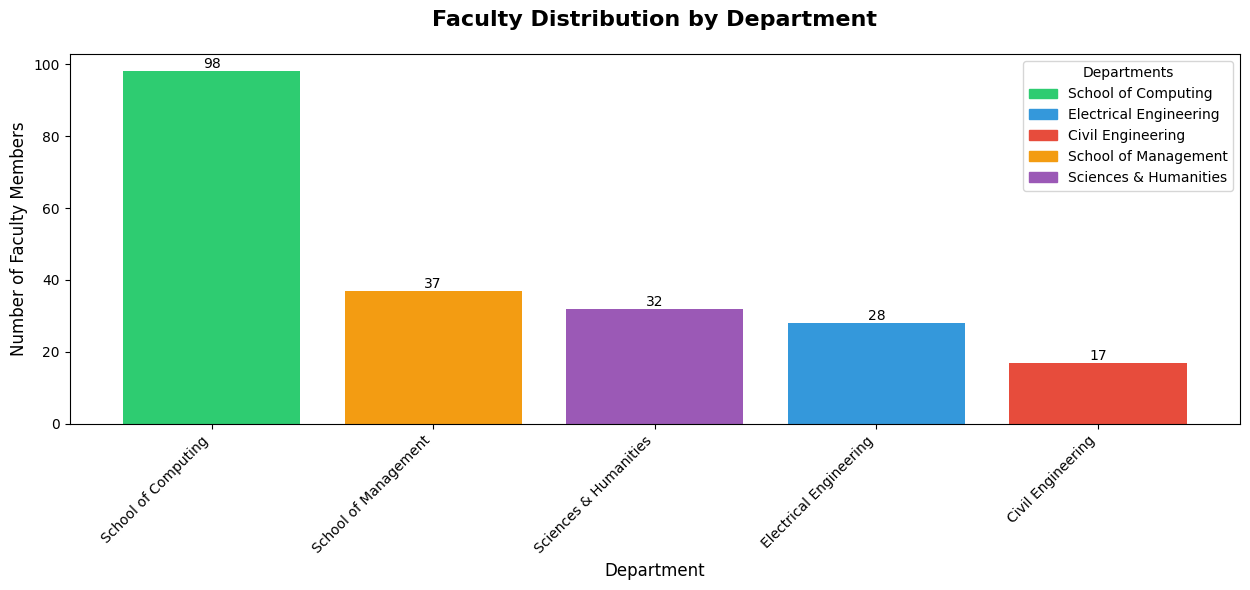

In [166]:
plt.figure(figsize=(14, 6))  

dept_names = {
    'fsc': 'School of Computing',
    'ee': 'Electrical Engineering',
    'cv': 'Civil Engineering',
    'fsm': 'School of Management',
    'ss': 'Sciences & Humanities'
}

dept_colors = {
    'School of Computing': '#2ecc71',    
    'Electrical Engineering': '#3498db',  
    'Civil Engineering': '#e74c3c',     
    'School of Management': '#f39c12',    
    'Sciences & Humanities': '#9b59b6'    
}

dept_counts = faculty_data['Department'].value_counts()
dept_counts.index = [dept_names[x] for x in dept_counts.index]

bars = plt.bar(range(len(dept_counts)), dept_counts.values, 
               color=[dept_colors[x] for x in dept_counts.index])

plt.title('Faculty Distribution by Department', pad=20, fontsize=16, weight='bold')
plt.xlabel('Department', fontsize=12)
plt.ylabel('Number of Faculty Members', fontsize=12)
plt.xticks(range(len(dept_counts)), dept_counts.index, rotation=45, ha='right')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom')

legend_elements = [plt.Rectangle((0,0),1,1, color=color, label=dept)
                  for dept, color in dept_colors.items()]
plt.legend(handles=legend_elements, title='Departments', 
          loc='upper right', bbox_to_anchor=(1.0, 1))

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

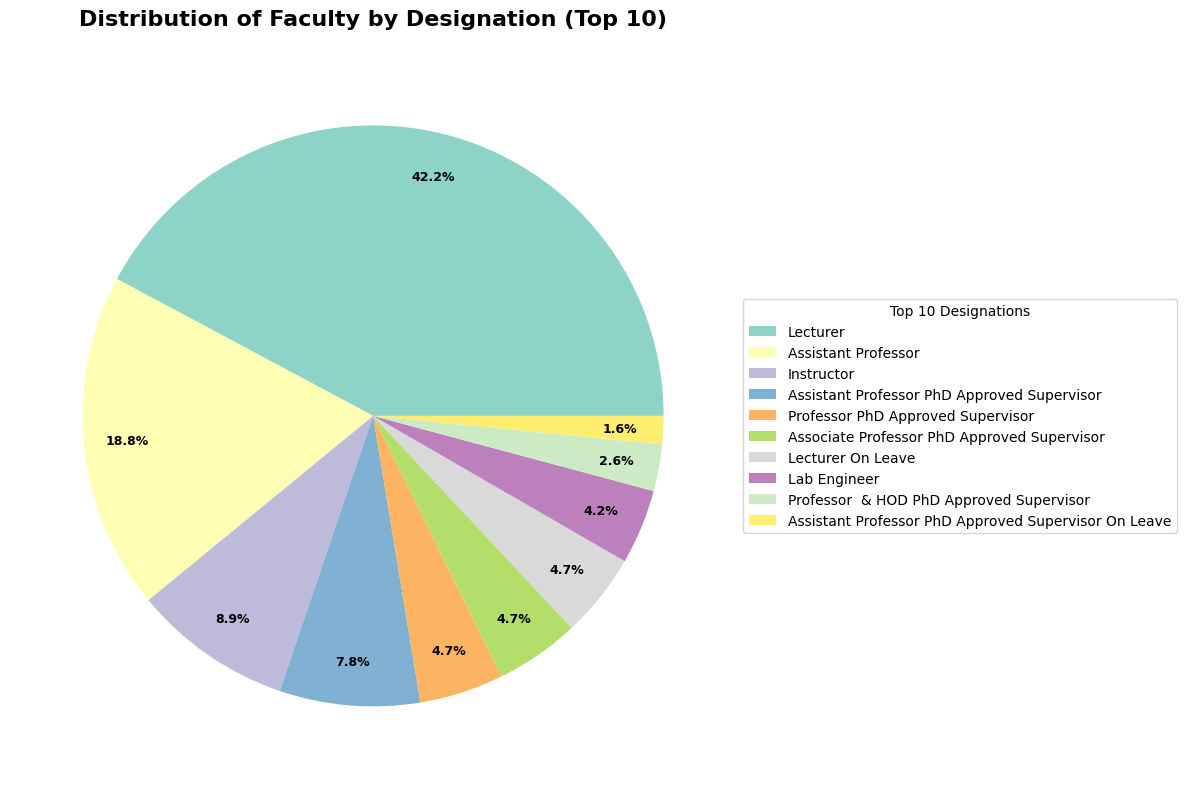

In [167]:
plt.figure(figsize=(12, 8))

desig_counts = faculty_data['Designation'].value_counts().head(10)
colors = plt.cm.Set3(np.linspace(0, 1, len(desig_counts)))
wedges, texts, autotexts = plt.pie(desig_counts, colors=colors,
                                  labels=[''] * len(desig_counts),
                                  autopct='%1.1f%%',
                                  pctdistance=0.85)

plt.legend(wedges, desig_counts.index,
          title="Top 10 Designations",
          loc="center left",
          bbox_to_anchor=(1.0, 0.5))

plt.setp(autotexts, size=9, weight='bold')

plt.title('Distribution of Faculty by Designation (Top 10)', 
         pad=20, fontsize=16, weight='bold')
plt.tight_layout()
plt.show()